In [136]:
import pandas as pd
import numpy as np
from pathlib import Path

### Extract Data

In [137]:
def load_data():
    data_dir = Path("Data") if Path("Data").exists() else Path(".")
    features = pd.read_csv(data_dir / "features.csv")
    stores = pd.read_csv(data_dir / "stores.csv")
    test = pd.read_csv(data_dir / "test.csv")
    train = pd.read_csv(data_dir / "train.csv")
    return features, stores, test, train

In [138]:
features, stores, test, train = load_data()
print(f"features: {features.shape}")
print(f"stores: {stores.shape}")
print(f"test: {test.shape}")
print(f"train: {train.shape}")

features: (8190, 12)
stores: (45, 3)
test: (115064, 4)
train: (421570, 5)


### features Dataset

In [139]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB


### Dataset "Shape"

In [140]:
print(features.shape)
print(stores.shape)
print(test.shape)
print(train.shape)

(8190, 12)
(45, 3)
(115064, 4)
(421570, 5)


### Converts Date to "datetime" formate

In [141]:
features["Date"] = pd.to_datetime(features["Date"])

In [142]:
features.isna().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

### Fill "null" values

In [143]:
features[["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]] = (
    features[["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].fillna(0)
)

In [144]:
features["CPI"] = features["CPI"].fillna(features["CPI"].mean())

In [145]:
features["Unemployment"] = features["Unemployment"].fillna(
    features.groupby("Store")["Unemployment"].transform("median")
)

 ### Stores Dataset

In [146]:
print(stores.info())

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB
None


In [147]:
print(stores.duplicated().sum())
print(stores.isnull().sum())

0
Store    0
Type     0
Size     0
dtype: int64


In [148]:
stores["Type"].value_counts()

Type
A    22
B    17
C     6
Name: count, dtype: int64

In [149]:
stores["Size"].describe()

count        45.000000
mean     130287.600000
std       63825.271991
min       34875.000000
25%       70713.000000
50%      126512.000000
75%      202307.000000
max      219622.000000
Name: Size, dtype: float64

### test Dataset

In [150]:
test.duplicated().sum()

np.int64(0)

In [151]:
test.isnull().sum()

Store        0
Dept         0
Date         0
IsHoliday    0
dtype: int64

### "train" Dataset

In [152]:
train.duplicated().sum()

np.int64(0)

In [153]:
train.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [154]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


### Convert Date to datetime


In [155]:
train["Date"] = pd.to_datetime(train["Date"])

### Merge Dataset

In [156]:
#features and stores.

full_data = pd.merge(features,stores,on="Store",how="left")

In [157]:
full_data.shape

(8190, 14)

In [158]:
full_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[us]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     8190 non-null   float64       
 5   MarkDown2     8190 non-null   float64       
 6   MarkDown3     8190 non-null   float64       
 7   MarkDown4     8190 non-null   float64       
 8   MarkDown5     8190 non-null   float64       
 9   CPI           8190 non-null   float64       
 10  Unemployment  8190 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
 12  Type          8190 non-null   str           
 13  Size          8190 non-null   int64         
dtypes: bool(1), datetime64[us](1), float64(9), int64(2), str(1)
memory usage: 839.9 KB


In [159]:
full_data = pd.merge(train, full_data, on=["Store", "Date"], how="left")

In [163]:
full_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

### IsHoliday_x vs IsHoliday_y

In [161]:
(full_data["IsHoliday_x"] == full_data["IsHoliday_y"]).all()

np.True_

### drop any one column and rename the columns

In [162]:
full_data = full_data.drop(columns=["IsHoliday_y"])
full_data = full_data.rename(columns={"IsHoliday_x": "IsHoliday"})

In [164]:
full_data.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size'],
      dtype='str')

## Exploratory Data Analysis (EDA)

### Weekly_Sales Distribution

In [165]:
full_data["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [166]:
(full_data["Weekly_Sales"] < 0).sum()

np.int64(1285)

### Holiday vs Non-Holiday Sales Comparison

In [168]:
full_data.groupby("IsHoliday")["Weekly_Sales"].describe()

,count,mean,std,min,25%,50%,75%,max
IsHoliday,,,,,,,,
False,391909.0,15901.445069,22330.747450,-4988.94,2079.75,7589.95,20131.21,406988.63
True,29661.0,17035.823187,27222.000409,-798.00,2078.54,7947.74,21189.25,693099.36


<Axes: title={'center': 'Total Weekly Sales Over Time'}, xlabel='Date'>

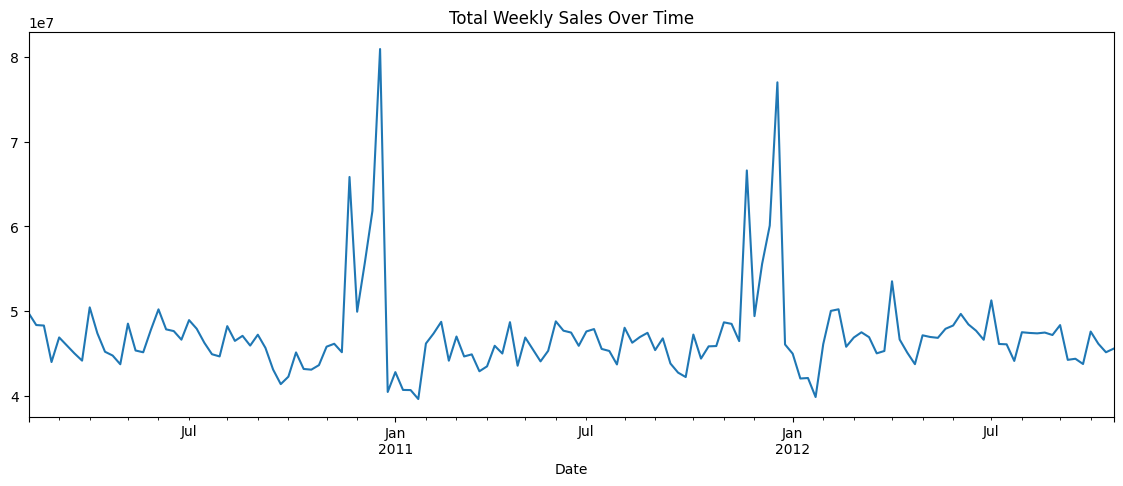

In [171]:
weekly_trend = full_data.groupby("Date")["Weekly_Sales"].sum()
weekly_trend.plot(figsize=(14,5), title="Total Weekly Sales Over Time")

In [172]:
weekly_trend.describe()

count    1.430000e+02
mean     4.711342e+07
std      5.444206e+06
min      3.959985e+07
25%      4.488059e+07
50%      4.624390e+07
75%      4.779202e+07
max      8.093142e+07
Name: Weekly_Sales, dtype: float64

### Store Type (A/B/C) wise sales

In [173]:
full_data.groupby("Type")["Weekly_Sales"].agg(["mean", "median", "count"])

,mean,median,count
Type,,,
A,20099.568043,10105.17,215478
B,12237.075977,6187.87,163495
C,9519.532538,1149.67,42597
